# Week 5 · Notebook 2 — Kernels and Hyperparameter Learning

## Learning objectives

1. Survey common kernels — RBF, Matérn, periodic, linear — and their inductive biases.
2. Derive the gradient of the **log marginal likelihood** with respect to kernel hyperparameters.
3. Optimise hyperparameters by L-BFGS and visualise the surface.
4. Diagnose underfitting / overfitting via held-out predictive log-likelihood.

---

## 1. A small kernel zoo

For inputs in $\mathbb{R}^d$ and $r = \Vert x-x'\Vert$:
- **RBF**: $k(r) = \sigma_f^2 \exp(-r^2/(2\ell^2))$ — infinitely differentiable, smooth.
- **Matérn-3/2**: $k(r) = \sigma_f^2 (1+\sqrt{3}r/\ell)\exp(-\sqrt{3}r/\ell)$ — once differentiable.
- **Matérn-5/2**: $k(r) = \sigma_f^2 (1+\sqrt{5}r/\ell + 5r^2/(3\ell^2))\exp(-\sqrt{5}r/\ell)$ — twice differentiable.
- **Periodic**: $k(x, x') = \sigma_f^2 \exp(-2\sin^2(\pi|x-x'|/p)/\ell^2)$.
- **Linear**: $k(x,x') = \sigma_f^2 x^\top x' + c$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(0)
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
BLUE, RED, GREEN = '#5B7DB1', '#C46D5E', '#7CA982'

def pairwise_dists(X1, X2):
    return np.sqrt(np.maximum(
        np.sum(X1**2, axis=1)[:, None] + np.sum(X2**2, axis=1)[None, :]
        - 2*X1 @ X2.T, 0.0))

def rbf_k(X1, X2, sf, ell):
    r = pairwise_dists(X1, X2)
    return sf**2 * np.exp(-0.5*(r/ell)**2)

def matern32_k(X1, X2, sf, ell):
    r = pairwise_dists(X1, X2)
    a = np.sqrt(3)*r/ell
    return sf**2 * (1+a) * np.exp(-a)

def matern52_k(X1, X2, sf, ell):
    r = pairwise_dists(X1, X2)
    a = np.sqrt(5)*r/ell
    return sf**2 * (1 + a + (5*r**2)/(3*ell**2)) * np.exp(-a)

def periodic_k(X1, X2, sf, ell, p):
    r = np.abs(X1 - X2.T)
    return sf**2 * np.exp(-2*np.sin(np.pi*r/p)**2 / ell**2)


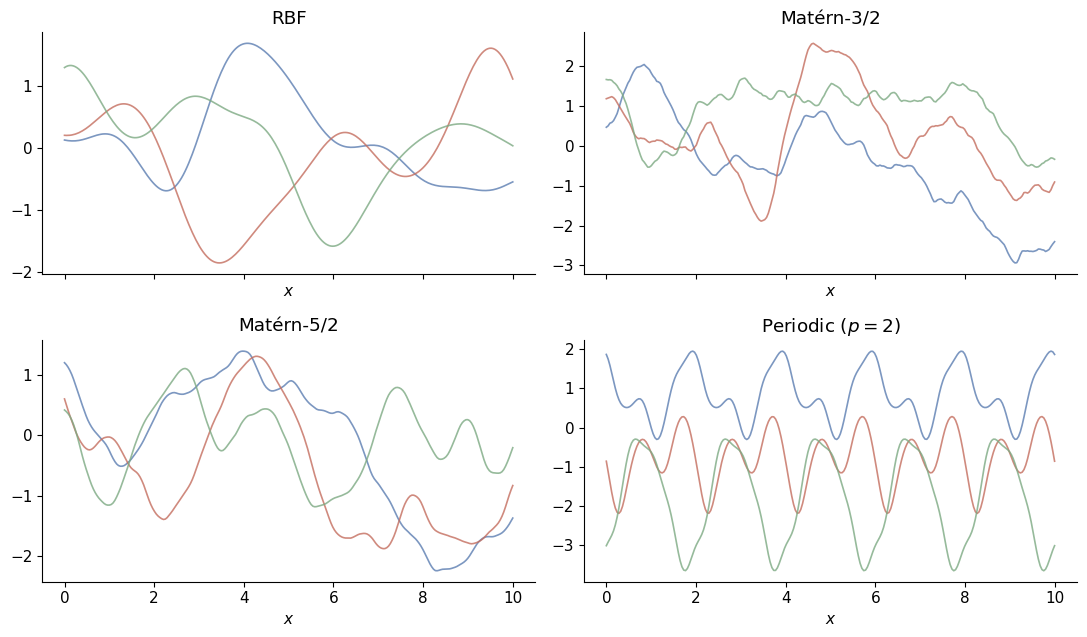

In [2]:
# Visualise samples from each kernel
xs = np.linspace(0, 10, 250).reshape(-1, 1)
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True)
specs = [
    ('RBF', rbf_k(xs, xs, 1.0, 1.0)),
    ('Matérn-3/2', matern32_k(xs, xs, 1.0, 1.0)),
    ('Matérn-5/2', matern52_k(xs, xs, 1.0, 1.0)),
    ('Periodic ($p=2$)', periodic_k(xs, xs, 1.0, 1.0, 2.0)),
]
for ax, (name, K) in zip(axes.ravel(), specs):
    L = np.linalg.cholesky(K + 1e-8*np.eye(len(xs)))
    for i in range(3):
        ax.plot(xs.ravel(), L @ rng.normal(size=len(xs)),
                color=[BLUE, RED, GREEN][i], lw=1.2, alpha=0.8)
    ax.set_title(name); ax.set_xlabel('$x$')
plt.tight_layout(); plt.show()


## 2. Marginal likelihood and its gradient

The log marginal likelihood under hyper-parameters $\theta$ (collecting $\sigma_f, \ell, \sigma_n$) is
$$
\log p(y\mid X, \theta) = -\tfrac12 y^\top K_\theta^{-1} y - \tfrac12 \log|K_\theta| - \tfrac{N}{2}\log 2\pi,\quad K_\theta := K(X,X) + \sigma_n^2 I.
$$
Its gradient is
$$
\frac{\partial \log p(y\mid X,\theta)}{\partial \theta_j}
 = \tfrac12 \,\mathrm{tr}\Bigl((\alpha\alpha^\top - K_\theta^{-1})\,\frac{\partial K_\theta}{\partial \theta_j}\Bigr),
\qquad \alpha = K_\theta^{-1} y.
$$

For the RBF, with $\theta = (\log\sigma_f, \log\ell, \log\sigma_n)$ (we optimise on log-scale for positivity),
$$
\frac{\partial K}{\partial \log\sigma_f} = 2 K_{\text{noise-free}},\quad
\frac{\partial K}{\partial \log\ell} = K_{\text{noise-free}} \cdot \frac{r^2}{\ell^2},\quad
\frac{\partial K}{\partial \log\sigma_n} = 2\sigma_n^2 I.
$$


In [3]:
def neg_log_marginal_and_grad(log_theta, X, y):
    log_sf, log_ell, log_sn = log_theta
    sf, ell, sn = np.exp(log_sf), np.exp(log_ell), np.exp(log_sn)
    N = len(y)
    r2 = (X**2).sum(1)[:, None] + (X**2).sum(1)[None, :] - 2*X @ X.T
    r2 = np.maximum(r2, 0.0)
    K0 = sf**2 * np.exp(-0.5*r2/ell**2)
    K = K0 + sn**2 * np.eye(N) + 1e-8*np.eye(N)
    L = np.linalg.cholesky(K)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
    log_ml = -0.5*y @ alpha - np.sum(np.log(np.diag(L))) - 0.5*N*np.log(2*np.pi)

    Kinv = np.linalg.solve(L.T, np.linalg.solve(L, np.eye(N)))
    A = np.outer(alpha, alpha) - Kinv
    # Derivatives wrt log-parameters
    dK_dsf  = 2 * K0
    dK_dell = K0 * (r2 / ell**2)
    dK_dsn  = 2 * sn**2 * np.eye(N)
    g_sf  = 0.5 * np.sum(A * dK_dsf)
    g_ell = 0.5 * np.sum(A * dK_dell)
    g_sn  = 0.5 * np.sum(A * dK_dsn)
    return -log_ml, -np.array([g_sf, g_ell, g_sn])


### 2.1 Verify the gradient with finite differences


In [4]:
X = np.linspace(-3, 3, 25).reshape(-1, 1)
y = np.sin(X.ravel()) + 0.15*rng.normal(size=25)
theta0 = np.log([1.0, 1.0, 0.2])
f0, g0 = neg_log_marginal_and_grad(theta0, X, y)
h = 1e-5
fd = []
for i in range(3):
    e = np.zeros(3); e[i] = h
    fp, _ = neg_log_marginal_and_grad(theta0 + e, X, y)
    fm, _ = neg_log_marginal_and_grad(theta0 - e, X, y)
    fd.append((fp - fm) / (2*h))
print('analytic grad   :', np.round(g0, 5))
print('finite diff grad:', np.round(fd, 5))


analytic grad   : [ 4.26221 -5.37288  9.29647]
finite diff grad: [ 4.26221 -5.37288  9.29647]


## 3. Optimise hyperparameters by L-BFGS


In [5]:
# Multiple restarts to escape local optima
best = None
for seed in range(8):
    rng_s = np.random.default_rng(seed)
    theta0 = rng_s.normal(0, 1.5, 3)
    res = minimize(neg_log_marginal_and_grad, theta0, args=(X, y),
                   jac=True, method='L-BFGS-B')
    if best is None or res.fun < best.fun:
        best = res
sf, ell, sn = np.exp(best.x)
print(f'optimised: sigma_f = {sf:.3f},  ell = {ell:.3f},  sigma_n = {sn:.3f}')
print(f'log marginal likelihood = {-best.fun:.3f}')


optimised: sigma_f = 0.835,  ell = 1.460,  sigma_n = 0.144
log marginal likelihood = 0.915


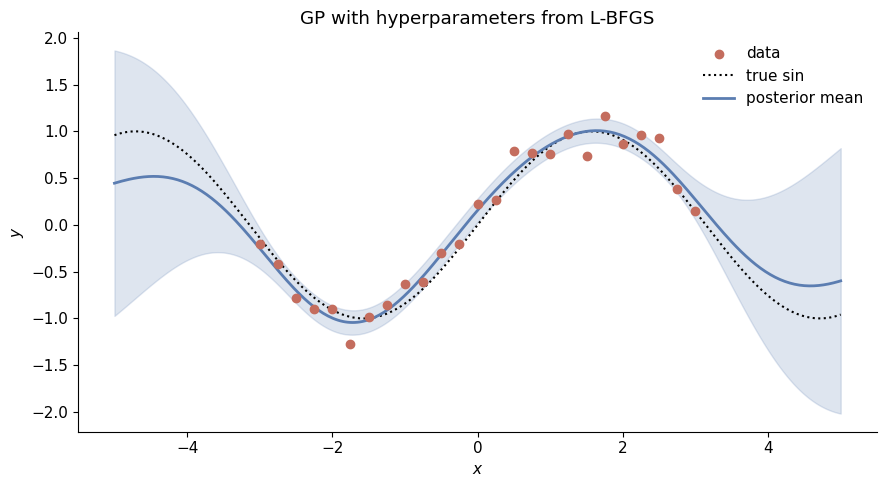

In [6]:
# Posterior fit with optimised parameters
def gp_predict(X, y, Xs, sf, ell, sn):
    K = sf**2 * np.exp(-0.5*pairwise_dists(X, X)**2/ell**2) + sn**2*np.eye(len(X)) + 1e-8*np.eye(len(X))
    Ks = sf**2 * np.exp(-0.5*pairwise_dists(X, Xs)**2/ell**2)
    Kss = sf**2 * np.exp(-0.5*pairwise_dists(Xs, Xs)**2/ell**2)
    L = np.linalg.cholesky(K)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
    mu = Ks.T @ alpha
    v = np.linalg.solve(L, Ks)
    var = np.diag(Kss) - np.sum(v**2, axis=0)
    return mu, np.sqrt(np.maximum(var, 0.0))

xs = np.linspace(-5, 5, 300).reshape(-1, 1)
mu, sd = gp_predict(X, y, xs, sf, ell, sn)

plt.figure()
plt.scatter(X, y, color=RED, zorder=5, label='data')
plt.plot(xs.ravel(), np.sin(xs.ravel()), 'k:', label='true sin')
plt.plot(xs.ravel(), mu, color=BLUE, lw=2, label='posterior mean')
plt.fill_between(xs.ravel(), mu-2*sd, mu+2*sd, alpha=0.2, color=BLUE)
plt.legend(frameon=False); plt.xlabel('$x$'); plt.ylabel('$y$')
plt.title('GP with hyperparameters from L-BFGS')
plt.tight_layout(); plt.show()


## 4. The marginal-likelihood landscape

Fix $\sigma_n$ at its optimum and visualise $\log p(y\mid X, \theta)$ over $(\log\ell, \log\sigma_f)$. The marginal likelihood automatically penalises both under- and over-fit kernels — this is the *Occam's razor* property of the Bayesian evidence.


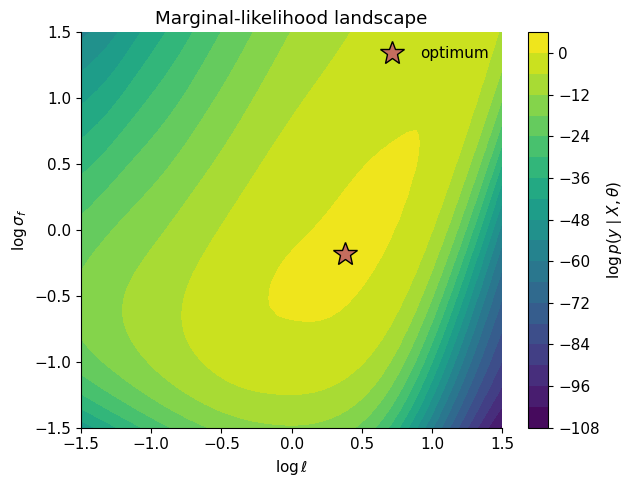

In [7]:
log_ells = np.linspace(-1.5, 1.5, 50)
log_sfs = np.linspace(-1.5, 1.5, 50)
Le, Lf = np.meshgrid(log_ells, log_sfs)
LL = np.zeros_like(Le)
log_sn_opt = best.x[2]
for i in range(Le.shape[0]):
    for j in range(Le.shape[1]):
        f, _ = neg_log_marginal_and_grad([Lf[i, j], Le[i, j], log_sn_opt], X, y)
        LL[i, j] = -f

plt.figure(figsize=(6.5, 5))
cs = plt.contourf(Le, Lf, LL, levels=18, cmap='viridis')
plt.colorbar(cs, label=r'$\log p(y\mid X,\theta)$')
plt.plot(best.x[1], best.x[0], '*', ms=18, color=RED, mec='k', label='optimum')
plt.xlabel(r'$\log \ell$'); plt.ylabel(r'$\log\sigma_f$')
plt.title('Marginal-likelihood landscape')
plt.legend(frameon=False)
plt.tight_layout(); plt.show()


## 5. Held-out predictive log-likelihood

Marginal likelihood selects hyper-parameters *given the model class*. The next question — is the model class right? — is best answered by predictive performance on held-out data.


In [8]:
# 5-fold pseudo-CV: leave one out
idx = np.arange(len(X))
ll = 0.0
for i in idx:
    mask = idx != i
    mu_i, sd_i = gp_predict(X[mask], y[mask], X[i:i+1], sf, ell, sn)
    # predictive variance must include observation noise
    pred_var = sd_i[0]**2 + sn**2
    ll += -0.5*np.log(2*np.pi*pred_var) - 0.5*(y[i]-mu_i[0])**2 / pred_var
print(f'mean LOO predictive log-likelihood = {ll/len(X):.3f}')


mean LOO predictive log-likelihood = 0.379


## 6. Summary

- Kernels encode prior assumptions about smoothness, periodicity, and stationarity.
- The log marginal likelihood is differentiable in hyper-parameters; L-BFGS with random restarts is the standard tool.
- The marginal-likelihood surface visualises model evidence trade-offs.
- LOO predictive log-likelihood validates the chosen kernel class.

---

## Exercises

1. Derive the gradient of the log marginal likelihood for the Matérn-5/2 kernel with respect to $\log\ell$.
2. Add an **additive** kernel $k = k_{\mathrm{RBF}} + k_{\mathrm{periodic}}$ and fit it to monthly CO2 data (Mauna Loa) restricted to 1990–2000. Plot the predicted seasonality and trend.
3. Demonstrate, on a 1-D dataset of your choice, that the marginal likelihood penalises too-small length-scales (overfitting) — show the score going down as $\ell\to 0$.
4. Implement automatic-relevance-determination by using a separate length-scale per input dimension. Fit it to a 3-D dataset where only one dimension is informative, and check that the redundant length-scales blow up.
